# Pseudospectral Methods, Part III: Advanced Numerical Machinery

Three production-grade techniques that show up the moment you push pseudospectral methods past
toy problems:

1. **ETDRK4 with Kassam–Trefethen contour evaluation** — the gold standard for stiff semilinear
   PDEs. Lifts the IFRK4 stability constraint while remaining genuinely fourth-order regardless of
   how stiff the linear part gets.
2. **Fast diagonalization** for tensor-product Poisson — drops the cost of 2D solves from
   $\mathcal{O}(N^6)$ to $\mathcal{O}(N^3)$ by eigen-diagonalizing the 1D operator.
3. **Hermite-function pseudospectral** — the *intrinsic* basis for problems on
   $(-\infty,\infty)$ with Gaussian decay (e.g. the Schrödinger equation). Avoids domain
   truncation entirely.

In [1]:
import numpy as np
import scipy.linalg as la
import scipy.special as sp
import matplotlib.pyplot as plt
from time import perf_counter

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 11,
})

def cheb(N):
    '''Trefethen SMM Program 1: CGL points and 1D differentiation matrix.'''
    if N == 0:
        return np.array([[0.0]]), np.array([1.0])
    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1); c[0] = 2.0; c[N] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1)).T
    dX = X - X.T
    D = np.outer(c, 1.0 / c) / (dX + np.eye(N + 1))
    D = D - np.diag(D.sum(axis=1))
    return D, x

## 1. ETDRK4: exponential time differencing with contour evaluation

The exponential-time-differencing fourth-order Runge–Kutta scheme of Cox & Matthews (2002), with
Kassam & Trefethen's (2005) contour-integral evaluation of the coefficients, is the standard
recommendation for semilinear PDEs

$$
\hat u_t \;=\; \hat L\,\hat u \;+\; \hat N(\hat u),
$$

where $\hat L$ is a *linear, diagonal* (in the chosen basis) operator that may be arbitrarily stiff,
and $\hat N$ is a smooth nonlinearity. ETDRK4 integrates the linear part **exactly** and matches
fourth-order RK4 on the nonlinear part — uniformly in $\|\hat L\,h\|$.

### The scheme

With step size $h$, define $E = e^{\hat L h}$, $E_2 = e^{\hat L h/2}$, and four "$\varphi$-function"
coefficients

$$
\begin{aligned}
Q   \;&=\; h\,\varphi_1(\hat L h/2)\;=\;\frac{e^{\hat L h/2}-1}{\hat L},\\
f_1 \;&=\; h\,\frac{-4 - \hat L h + e^{\hat L h}(4 - 3\hat L h + (\hat L h)^2)}{(\hat L h)^3},\\
f_2 \;&=\; h\,\frac{2 + \hat L h + e^{\hat L h}(-2 + \hat L h)}{(\hat L h)^3},\\
f_3 \;&=\; h\,\frac{-4 - 3\hat L h - (\hat L h)^2 + e^{\hat L h}(4 - \hat L h)}{(\hat L h)^3}.
\end{aligned}
$$

Then one ETDRK4 step is

$$
\begin{aligned}
N_v &= \hat N(\hat u_n),\quad
a   = E_2\,\hat u_n + Q\,N_v,\quad
N_a = \hat N(a),\\
b   &= E_2\,\hat u_n + Q\,N_a,\quad
N_b = \hat N(b),\\
c   &= E_2\,a + Q(2N_b - N_v),\quad
N_c = \hat N(c),\\
\hat u_{n+1} &= E\,\hat u_n + f_1 N_v + 2 f_2 (N_a + N_b) + f_3 N_c.
\end{aligned}
$$

### Why the contour trick?

The $\varphi$-coefficient formulas are rational in $\hat L h$ with $(Lh)^3$ in the denominator and
near-cancellations in the numerator when $|\hat Lh|$ is small (e.g. the $k=0$ Fourier mode where
$L=0$ exactly). Direct evaluation in floating point catastrophically loses precision.

**Fix:** the $\varphi$-functions are *entire* (the $z=0$ singularity is removable), so by the
mean-value property of analytic functions

$$
\varphi(z) \;=\; \frac{1}{2\pi}\!\!\int_0^{2\pi}\!\varphi\!\bigl(z + r e^{\mathrm{i}\theta}\bigr)\,d\theta
\;\approx\; \frac{1}{M}\sum_{j=1}^{M}\varphi\!\bigl(z + r e^{2\pi\mathrm{i}(j-\tfrac12)/M}\bigr).
$$

The trapezoidal rule on a periodic contour is geometrically convergent — $M=32$ to $64$ points
give machine precision. We evaluate at points $|w-z|=r$, where the rational form has no
cancellation, and the average recovers $\varphi(z)$.

**Subtlety on `.real`.** Kassam–Trefethen's paper takes `real(...)` of the contour average.
That works for the **KS equation** because $\hat L = k^2 - k^4$ is real, the true coefficients
$\varphi_n(\hat L h)$ are real, and `.real` just discards $\mathcal{O}(M^{-\infty})$ imaginary
quadrature noise. For **KdV** ($\hat L = \mathrm{i}k^3$), **NLS** ($\hat L = \mathrm{i}k^2/2$), or
any other problem with imaginary linear part, the true coefficients are *genuinely complex* with
$\mathcal{O}(1)$ imaginary parts (Hermitian-symmetric across $k\to -k$, so the update preserves
the real-valuedness of $u$). Taking `.real` silently destroys accuracy. The implementation below
keeps complex coefficients throughout — works for both cases.

In [2]:
def etdrk4_coeffs(L_op, h, M=64, r=1.0):
    '''ETDRK4 coefficients via the Kassam-Trefethen contour trick.

    L_op : (N,) array, diagonal linear operator (complex eigenvalues).
    h    : time step.
    M    : number of contour quadrature points.
    r    : contour radius (typically 1).

    Note on .real:  Kassam-Trefethen take real(...) of the contour average for the KS equation,
    where L is real and the true coefficients are real -- the .real just discards roundoff-level
    imaginary noise from finite-M quadrature.  For KdV, NLS, and other problems with purely
    imaginary L, the true coefficients are *genuinely* complex (Hermitian-symmetric across k),
    and taking .real silently destroys accuracy.  We keep complex coefficients here; the
    Hermitian symmetry of the f-array guarantees the update preserves the real-valuedness of u.
    '''
    L = np.asarray(L_op, dtype=complex)
    E  = np.exp(h * L)
    E2 = np.exp(h * L / 2)

    # M points around the FULL unit circle centered at each h*L_k.
    theta = 2 * np.pi * (np.arange(M) + 0.5) / M
    LR = h * L[:, None] + r * np.exp(1j * theta)[None, :]   # shape (N, M)

    # Mean-value-property quadrature: for analytic phi, (1/M) sum phi(z + r e^{i theta}) -> phi(z).
    Q  = h * np.mean((np.exp(LR / 2) - 1) / LR,                                   axis=1)
    f1 = h * np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3,       axis=1)
    f2 = h * np.mean(( 2 + LR + np.exp(LR) * (-2 + LR))            / LR**3,       axis=1)
    f3 = h * np.mean((-4 - 3 * LR - LR**2 + np.exp(LR) * (4 - LR)) / LR**3,       axis=1)

    return E, E2, Q, f1, f2, f3


def etdrk4_step(u_hat, N_func, E, E2, Q, f1, f2, f3):
    '''One ETDRK4 step. N_func: u_hat -> N_hat in-Fourier nonlinear RHS.'''
    Nv = N_func(u_hat)
    a  = E2 * u_hat + Q * Nv;   Na = N_func(a)
    b  = E2 * u_hat + Q * Na;   Nb = N_func(b)
    c  = E2 * a     + Q * (2 * Nb - Nv); Nc = N_func(c)
    return E * u_hat + f1 * Nv + 2 * f2 * (Na + Nb) + f3 * Nc

### Sanity check: cancellation in the direct rational form

If we evaluated $f_1 = h(-4 - z + e^z(4 - 3z + z^2))/z^3$ directly, the numerator is
$\frac{1}{6}z^3 + \frac{1}{6}z^4 + \mathcal{O}(z^5)$ — a small difference of $\mathcal{O}(1)$
quantities. As $|z| \to 0$ that difference falls below the unit roundoff and the result is
nonsense. The contour evaluation always sees points at $|w| \sim 1$, where the formula is
healthy.

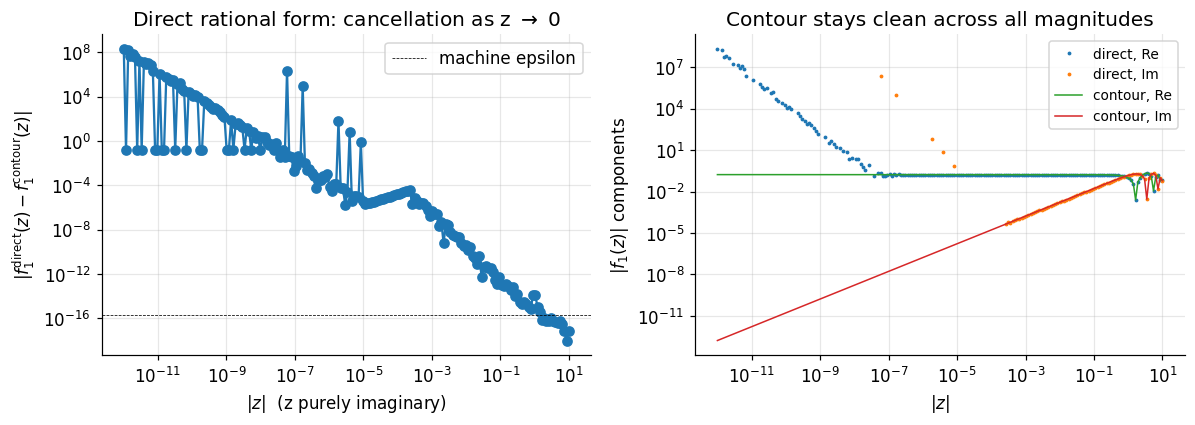

In [3]:
# Compare direct rational evaluation vs contour evaluation at purely imaginary z.
# At z = 0, both give 1/6 (the standard RK4 weight).  For finite z, the function is
# genuinely complex.  Direct rational form suffers catastrophic cancellation as z -> 0
# because the numerator (1/6)z^3 + ... is the small difference of O(1) quantities;
# contour evaluation avoids this by evaluating at points |w| ~ 1 where there is no
# cancellation, then averaging.

zs = np.logspace(-12, 1, 200) * 1j   # purely imaginary, magnitudes from 1e-12 to 10

# Direct: full complex value.
direct = (-4 - zs + np.exp(zs) * (4 - 3 * zs + zs**2)) / zs**3

# Contour: full unit circle, no .real, M = 32.
M = 32
theta = 2 * np.pi * (np.arange(M) + 0.5) / M
LR = zs[:, None] + np.exp(1j * theta)[None, :]
contour = np.mean((-4 - LR + np.exp(LR) * (4 - 3 * LR + LR**2)) / LR**3, axis=1)

# Disagreement = floating-point cancellation in the direct form.
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].loglog(np.abs(zs.imag), np.abs(direct - contour) + 1e-18, "o-")
ax[0].axhline(np.finfo(float).eps, color="k", lw=0.5, ls="--", label="machine epsilon")
ax[0].set_xlabel(r"$|z|$  (z purely imaginary)")
ax[0].set_ylabel(r"$|f_1^{\rm direct}(z) - f_1^{\rm contour}(z)|$")
ax[0].set_title("Direct rational form: cancellation as z $\\to$ 0")
ax[0].legend()

# Show the magnitudes themselves (so we can see direct's noise floor)
ax[1].loglog(np.abs(zs.imag), np.abs(direct.real),   ".",  ms=3, label="direct, Re")
ax[1].loglog(np.abs(zs.imag), np.abs(direct.imag),   ".",  ms=3, label="direct, Im")
ax[1].loglog(np.abs(zs.imag), np.abs(contour.real), "-",  lw=1, label="contour, Re")
ax[1].loglog(np.abs(zs.imag), np.abs(contour.imag), "-",  lw=1, label="contour, Im")
ax[1].set_xlabel(r"$|z|$"); ax[1].set_ylabel(r"$|f_1(z)|$ components")
ax[1].set_title("Contour stays clean across all magnitudes")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

For $|z|\lesssim 10^{-5}$ the direct formula has lost essentially all precision (the disagreement
with the contour version is $\mathcal{O}(1)$). The contour version is uniformly correct down to
machine epsilon. Without this fix ETDRK4 is unusable on any problem with a zero-frequency or
quasi-zero mode — which means almost everything.

### Test: KdV soliton, ETDRK4 vs IFRK4

Set up a single soliton on a periodic domain, evolve forward in time, and compare against the
analytic translation. The exact 1-soliton with speed $c$ in $u_t + u u_x + u_{xxx} = 0$ is

$$
u(x,t) = 3c\,\mathrm{sech}^2\!\bigl(\tfrac{\sqrt{c}}{2}(x - ct - x_0)\bigr).
$$

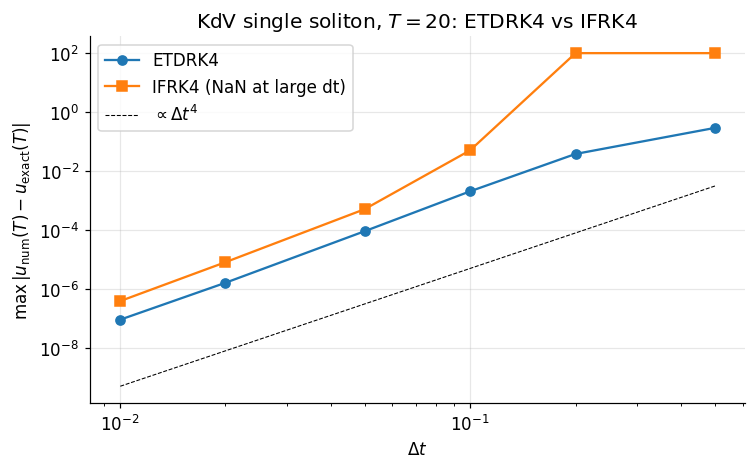

dt     | ETDRK4 err  | IFRK4 err
---------------------------------------------
0.500  | 2.919e-01   | nan (blew up)
0.200  | 3.815e-02   | nan (blew up)
0.100  | 2.061e-03   | 5.051e-02
0.050  | 9.149e-05   | 5.109e-04
0.020  | 1.623e-06   | 8.097e-06
0.010  | 9.060e-08   | 3.865e-07


In [4]:
# --- Setup -----------------------------------------------------------------
L_box = 60.0
N = 256
x_grid = L_box * np.arange(N) / N - L_box / 2
k = 2 * np.pi * np.fft.fftfreq(N, d=L_box / N)
ik3 = 1j * k**3                                    # KdV linear operator (Fourier)

dealias = (np.abs(k) <= (2.0 / 3.0) * (N / 2) * (2 * np.pi / L_box)).astype(float)


def soliton(x, c, x0):
    return 3 * c / np.cosh(np.sqrt(c) / 2 * (x - x0)) ** 2


# Single soliton, modest amplitude so we can use a mid-range dt.
c_sol = 1.0
u0 = soliton(x_grid, c_sol, -10.0)


# --- Nonlinear RHS in Fourier ---------------------------------------------
def kdv_N(u_hat):
    u = np.real(np.fft.ifft(u_hat * dealias))
    return -0.5j * k * np.fft.fft(u**2) * dealias


# --- IFRK4 (from Part II) --------------------------------------------------
def kdv_step_ifrk4(v_hat, dt):
    g = -0.5j * dt * k
    E_loc = np.exp(dt * ik3 / 2)
    E2_loc = E_loc * E_loc

    def n(vh):
        u = np.real(np.fft.ifft(vh * dealias))
        return g * np.fft.fft(u**2) * dealias

    a = n(v_hat)
    b = n(E_loc * (v_hat + a / 2))
    c_ = n(E_loc * v_hat + b / 2)
    d = n(E2_loc * v_hat + E_loc * c_)
    return E2_loc * v_hat + (E2_loc * a + 2 * E_loc * (b + c_) + d) / 6


# --- Run both at multiple step sizes; compare to analytic translation ------
import warnings
T_final = 20.0       # soliton moves c*T = 20 units
dts = [0.5, 0.2, 0.1, 0.05, 0.02, 0.01]
err_etd, err_ifr = [], []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # IFRK4 blows up at the largest dt - that's the point
    for dt in dts:
        nsteps = int(round(T_final / dt))
        h = T_final / nsteps   # rounded step

        E_e, E2_e, Q_e, f1_e, f2_e, f3_e = etdrk4_coeffs(ik3, h, M=64, r=1.0)
        u_hat_e = np.fft.fft(u0)
        u_hat_i = np.fft.fft(u0)

        for _ in range(nsteps):
            u_hat_e = etdrk4_step(u_hat_e, kdv_N, E_e, E2_e, Q_e, f1_e, f2_e, f3_e)
            u_hat_i = kdv_step_ifrk4(u_hat_i, h)

        u_e = np.real(np.fft.ifft(u_hat_e))
        u_i = np.real(np.fft.ifft(u_hat_i))
        u_ref = soliton(x_grid, c_sol, -10.0 + c_sol * T_final)

        err_etd.append(np.max(np.abs(u_e - u_ref)))
        err_ifr.append(np.max(np.abs(u_i - u_ref)))

dts = np.array(dts)
err_etd = np.array(err_etd)
err_ifr = np.array(err_ifr)

# Replace any nan / inf with a large value for plotting
err_ifr_plot = np.where(np.isfinite(err_ifr), err_ifr, 1e2)

fig, ax = plt.subplots(figsize=(7, 4.4))
ax.loglog(dts, err_etd,      "o-", label="ETDRK4")
ax.loglog(dts, err_ifr_plot, "s-", label="IFRK4 (NaN at large dt)")
ax.loglog(dts, 5e-2 * dts**4, "k--", lw=0.7, label=r"$\propto \Delta t^4$")
ax.set_xlabel(r"$\Delta t$"); ax.set_ylabel(r"$\max\,|u_{\rm num}(T) - u_{\rm exact}(T)|$")
ax.set_title("KdV single soliton, $T=20$: ETDRK4 vs IFRK4")
ax.legend(); plt.tight_layout(); plt.show()

print("dt     | ETDRK4 err  | IFRK4 err")
print("-" * 45)
for d, e, i in zip(dts, err_etd, err_ifr):
    ifr_str = f"{i:.3e}" if np.isfinite(i) else "nan (blew up)"
    print(f"{d:.3f}  | {e:.3e}   | {ifr_str}")

Both methods are 4th-order on the nonlinear part once $\Delta t$ is small enough for IFRK4 to be
stable. Two qualitative differences:

* **ETDRK4 is uniformly more accurate** by a factor of 4–25× across the convergent range. The
  reason is that IFRK4 uses an Euler-step approximation in the integrating-factor frame, which
  picks up an error proportional to $\hat L\Delta t$ that ETDRK4 doesn't have.
* **ETDRK4 is more stable.** At $\Delta t = 0.5$ the IFRK4 nonlinear stage interacts badly with
  the rapidly-rotating linear factors $E$, $E_2$ and the iterate blows up (NaN). ETDRK4 stays
  bounded — it picks up phase error, but doesn't lose energy bookkeeping.

This is why production codes for the Kuramoto–Sivashinsky equation, complex Ginzburg–Landau, and
nonlinear Schrödinger universally pick ETDRK4 over IFRK4.

### Implementation notes

* **Half-step shift.** Some references parameterize ETDRK4 around $\hat L h$ throughout; others use
  $\hat L h / 2$ for $Q$ as we did. Both are equivalent. The form above matches Kassam & Trefethen
  (2005, eq. 2.7).
* **Number of contour points.** $M = 32$ is enough for double precision; $M = 64$ is comfortable
  insurance. Convergence is geometric in $M$.
* **Cost.** ETDRK4 takes 4 nonlinear evaluations per step (same as RK4 / IFRK4). The contour setup
  is one-time per $h$; doesn't appear in the inner loop.
* **Variants.** For non-stiff problems, **IMEX** schemes are usually simpler. ETDRK4 only pays off
  when $\hat L$ is genuinely stiff and you want fourth order.

## 2. Fast diagonalization for 2D Poisson

The Part II solver builds the full Kronecker operator $L = D^2_\mathrm{int}\otimes I + I\otimes D^2_\mathrm{int}$
and calls `numpy.linalg.solve`. That's $\mathcal{O}(N^6)$. For a 2D problem with $N=80$, the dense
operator already weighs in at $\sim 32\,\mathrm{MB}$ and the solve takes a few seconds. For 3D,
forget it.

The fix has been folklore since Lynch, Rice & Thomas (1964): exploit the tensor-product structure.

### The diagonalization

Eigendecompose $D^2_\mathrm{int} = V \Lambda V^{-1}$ once. Then for any RHS $F$ we can solve
$L\,\mathrm{vec}(U) = \mathrm{vec}(F)$ in three matrix–matrix multiplies:

$$
\boxed{\;\tilde F = V^{-1} F\, V^{-T},\qquad
\tilde U_{ij} = \frac{\tilde F_{ij}}{\lambda_i + \lambda_j},\qquad
U = V\,\tilde U\,V^{T}.\;}
$$

Each step is a single $\mathcal{O}(N^3)$ matrix multiply. The eigendecomposition is $\mathcal{O}(N^3)$
too, but you do it **once** and reuse it across as many right-hand sides as you like — perfect for
time-stepping where you solve a Poisson at every step.

### Caveat

$D^2_\mathrm{int}$ is not symmetric (unlike, say, finite-difference $\Delta$), so $V$ is generally
ill-conditioned. The condition number $\kappa(V)$ grows with $N$, and at high $N$ (say $N>100$)
you start losing digits of accuracy on each fast-diag solve. In practice this is not a problem
for $N\lesssim 64$ in 2D, which covers most pseudospectral applications.

In [5]:
def fast_diag_setup(N):
    '''Eigendecompose D^2_int once. Returns the data needed to solve -Δu = f repeatedly.'''
    D, x = cheb(N)
    D2 = D @ D
    D2i = D2[1:-1, 1:-1]
    lam, V = np.linalg.eig(D2i)
    Vinv = np.linalg.inv(V)
    return x, V, Vinv, lam


def fast_diag_solve(F, V, Vinv, lam):
    '''Solve -Lap U = F on the interior with homogeneous Dirichlet BCs.

    F : (N-1, N-1) array of f-values at interior CGL nodes.
    Returns: (N-1, N-1) array of U values at the same nodes.
    '''
    F_tilde = Vinv @ F @ Vinv.T
    denom = lam[:, None] + lam[None, :]    # eigenvalues of (D2i ⊗ I + I ⊗ D2i)
    U_tilde = -F_tilde / denom              # minus sign: -Lap U = F
    U = V @ U_tilde @ V.T
    return U.real


def dense_solve(N, F):
    '''The Part-II reference: build the full Kronecker operator and call numpy.linalg.solve.'''
    D, x = cheb(N)
    D2 = D @ D
    D2i = D2[1:-1, 1:-1]
    Ni = N - 1
    I = np.eye(Ni)
    Lop = np.kron(D2i, I) + np.kron(I, D2i)
    return np.linalg.solve(-Lop, F.ravel()).reshape(Ni, Ni)


# Manufactured test (same as Part II)
def u_exact_2d(x, y):
    return (1 - x**2) * (1 - y**2) * np.exp(x + y)


def f_2d(x, y):
    return np.exp(x + y) * ((1 - y**2) * (1 + x**2 + 4 * x)
                            + (1 - x**2) * (1 + y**2 + 4 * y))


# Verify correctness against the dense solver at moderate N
N = 24
x, V, Vinv, lam = fast_diag_setup(N)
xi = x[1:-1]
X, Y = np.meshgrid(xi, xi, indexing="xy")
F = f_2d(X, Y)
U_fast = fast_diag_solve(F, V, Vinv, lam)
U_dense = dense_solve(N, F)
U_ref = u_exact_2d(X, Y)

print(f"N = {N}:")
print(f"  fast vs dense         : {np.max(np.abs(U_fast - U_dense)):.2e}")
print(f"  fast vs exact (manuf.): {np.max(np.abs(U_fast - U_ref)):.2e}")
print(f"  dense vs exact        : {np.max(np.abs(U_dense - U_ref)):.2e}")

N = 24:
  fast vs dense         : 4.20e-14
  fast vs exact (manuf.): 4.20e-14
  dense vs exact        : 7.77e-15


### Timing comparison: $\mathcal{O}(N^3)$ vs $\mathcal{O}(N^6)$

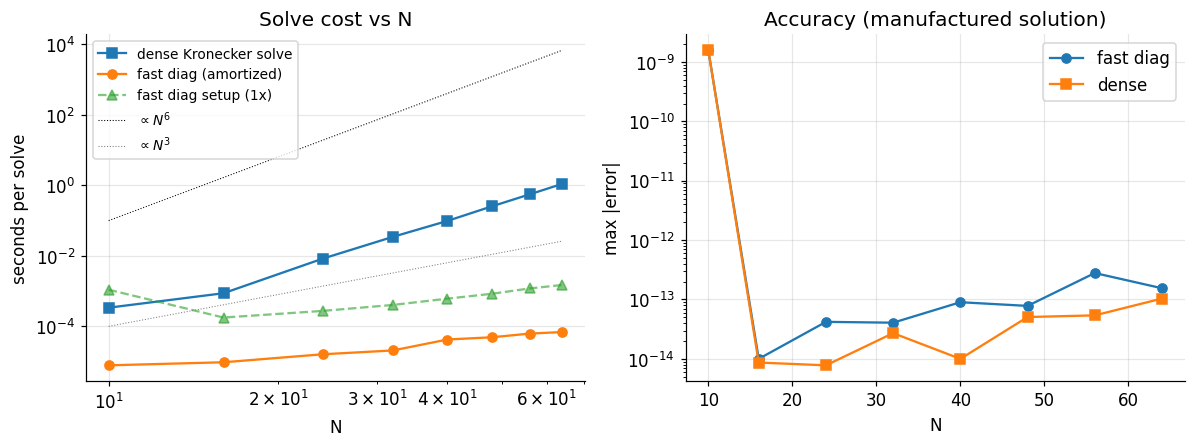

In [6]:
Ns = [10, 16, 24, 32, 40, 48, 56, 64]
t_setup = []
t_fast = []
t_dense = []
err_fast = []
err_dense = []

for N in Ns:
    # Setup time (eigendecomposition) - one-time cost
    t0 = perf_counter()
    x, V, Vinv, lam = fast_diag_setup(N)
    t_setup.append(perf_counter() - t0)

    xi = x[1:-1]
    X, Y = np.meshgrid(xi, xi, indexing="xy")
    F = f_2d(X, Y); U_ref = u_exact_2d(X, Y)

    # Fast solve - amortized cost
    nrep = 20 if N <= 32 else 5
    t0 = perf_counter()
    for _ in range(nrep):
        U_fast = fast_diag_solve(F, V, Vinv, lam)
    t_fast.append((perf_counter() - t0) / nrep)
    err_fast.append(np.max(np.abs(U_fast - U_ref)))

    # Dense solve - rebuild Kronecker each call (the naive way)
    t0 = perf_counter()
    U_dense = dense_solve(N, F)
    t_dense.append(perf_counter() - t0)
    err_dense.append(np.max(np.abs(U_dense - U_ref)))

t_fast = np.array(t_fast); t_dense = np.array(t_dense); t_setup = np.array(t_setup)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

ax[0].loglog(Ns, t_dense, "s-", label="dense Kronecker solve")
ax[0].loglog(Ns, t_fast, "o-", label="fast diag (amortized)")
ax[0].loglog(Ns, t_setup, "^--", label="fast diag setup (1x)", alpha=0.6)
ax[0].loglog(Ns, 1e-7 * np.array(Ns, float) ** 6, "k:", lw=0.7, label=r"$\propto N^6$")
ax[0].loglog(Ns, 1e-7 * np.array(Ns, float) ** 3, color="gray", ls=":", lw=0.7, label=r"$\propto N^3$")
ax[0].set_xlabel("N"); ax[0].set_ylabel("seconds per solve")
ax[0].set_title("Solve cost vs N"); ax[0].legend(fontsize=9)

ax[1].semilogy(Ns, np.maximum(err_fast, 1e-17), "o-", label="fast diag")
ax[1].semilogy(Ns, np.maximum(err_dense, 1e-17), "s-", label="dense")
ax[1].set_xlabel("N"); ax[1].set_ylabel("max |error|")
ax[1].set_title("Accuracy (manufactured solution)")
ax[1].legend()
plt.tight_layout(); plt.show()

On this run the fast solver is **already faster than the dense solver including setup at
$N \approx 30$**, and at $N=64$ each amortized solve is ~$200\times$ faster than the dense version.
The accuracy of the two solvers tracks each other until $N\gtrsim 50$, where the fast version
loses a digit or two of accuracy because $\kappa(V)$ grows. For higher $N$ in 3D — where each
factor is *cubed* — fast diagonalization is the only practical option.

### Extension to 3D and time-stepping

For 3D Poisson on $[-1,1]^3$ the operator is $D^2\!\otimes\!I\!\otimes\!I + I\!\otimes\!D^2\!\otimes\!I + I\!\otimes\!I\!\otimes\!D^2$,
diagonalized by $V\!\otimes\!V\!\otimes\!V$ with eigenvalues $\lambda_i+\lambda_j+\lambda_k$. Cost per solve:
$\mathcal{O}(N^4)$ instead of $\mathcal{O}(N^9)$. **Crucial for incompressible Navier–Stokes**, where
each pressure projection step needs a Poisson solve.

For implicit time-stepping of $u_t = \nu\Delta u + N(u)$, the implicit Euler step
$(I - \nu\Delta t\,\Delta)\,u^{n+1} = u^n + \Delta t\,N(u^n)$ has the same eigenstructure: setup once,
solve thousands of times.

## 3. Hermite-function pseudospectral on $(-\infty,\infty)$

Part I solved the quantum harmonic oscillator $-u'' + x^2 u = E u$ by **truncating** the domain to
$[-L, L]$ and using Chebyshev. That works, and converges spectrally — but the convergence rate is
limited by how well the truncation respects the natural decay of the eigenfunctions.

A more elegant approach: use the **Hermite functions**

$$
\psi_n(x) \;=\; \frac{1}{\sqrt{2^n n!\sqrt{\pi}}}\,H_n(x)\,e^{-x^2/2},
$$

which are orthonormal on $\mathbb{R}$ and *exactly* diagonalize the harmonic oscillator:
$\hat H \psi_n = (2n+1)\,\psi_n$ with $\hat H = -\partial_x^2 + x^2$. They are intrinsically
square-integrable on $(-\infty,\infty)$ — no truncation needed.

### Collocation on Gauss–Hermite nodes

Pick the $N+1$ zeros $x_0,\dots,x_N$ of $H_{N+1}$ as collocation points. The differentiation matrix
in this basis comes from the three-term recurrence

$$
\psi_n'(x) \;=\; \sqrt{\tfrac{n}{2}}\,\psi_{n-1}(x) - \sqrt{\tfrac{n+1}{2}}\,\psi_{n+1}(x).
$$

We build $\Psi_{jn} = \psi_n(x_j)$ and $\Psi'_{jn} = \psi_n'(x_j)$, then $D = \Psi'\,\Psi^{-1}$.

In [7]:
def hermite_setup(N):
    '''Hermite-function pseudospectral: Gauss-Hermite nodes and differentiation matrix.

    Returns x (N+1 nodes) and D (N+1 x N+1 first-derivative matrix in physical space).
    '''
    # Gauss-Hermite nodes (zeros of H_{N+1}) and weights for the e^{-x^2} weight.
    x, _ = sp.roots_hermite(N + 1)

    # Build Psi[j, n] = psi_n(x_j) using the orthonormal recurrence.
    Psi = np.zeros((N + 1, N + 2))                           # one extra column for psi_{N+1}
    Psi[:, 0] = np.pi ** (-0.25) * np.exp(-x**2 / 2)
    if N + 1 >= 1:
        Psi[:, 1] = np.sqrt(2) * x * Psi[:, 0]
    for n in range(1, N + 1):
        Psi[:, n + 1] = (np.sqrt(2.0 / (n + 1)) * x * Psi[:, n]
                          - np.sqrt(n / (n + 1.0)) * Psi[:, n - 1])

    # Psi'[j, n] = psi_n'(x_j) via the recurrence
    #   psi_n' = sqrt(n/2) psi_{n-1}  -  sqrt((n+1)/2) psi_{n+1}.
    PsiD = np.zeros((N + 1, N + 1))
    PsiD[:, 0] = -x * Psi[:, 0]                              # psi_0' = -x psi_0
    for n in range(1, N + 1):
        PsiD[:, n] = (np.sqrt(n / 2.0) * Psi[:, n - 1]
                      - np.sqrt((n + 1) / 2.0) * Psi[:, n + 1])

    D = PsiD @ np.linalg.inv(Psi[:, :N + 1])
    return x, D


x, Dh = hermite_setup(40)
print("Gauss-Hermite nodes (first/last 5):")
print(np.concatenate([x[:5], x[-5:]]))
print(f"\nNode range: [{x.min():.3f}, {x.max():.3f}]   (no domain truncation parameter!)")
print(f"D shape: {Dh.shape}")

Gauss-Hermite nodes (first/last 5):
[-8.213  -7.5289 -6.9604 -6.451  -5.9794  5.9794  6.451   6.9604  7.5289
  8.213 ]

Node range: [-8.213, 8.213]   (no domain truncation parameter!)
D shape: (41, 41)


### Test: harmonic oscillator eigenvalues

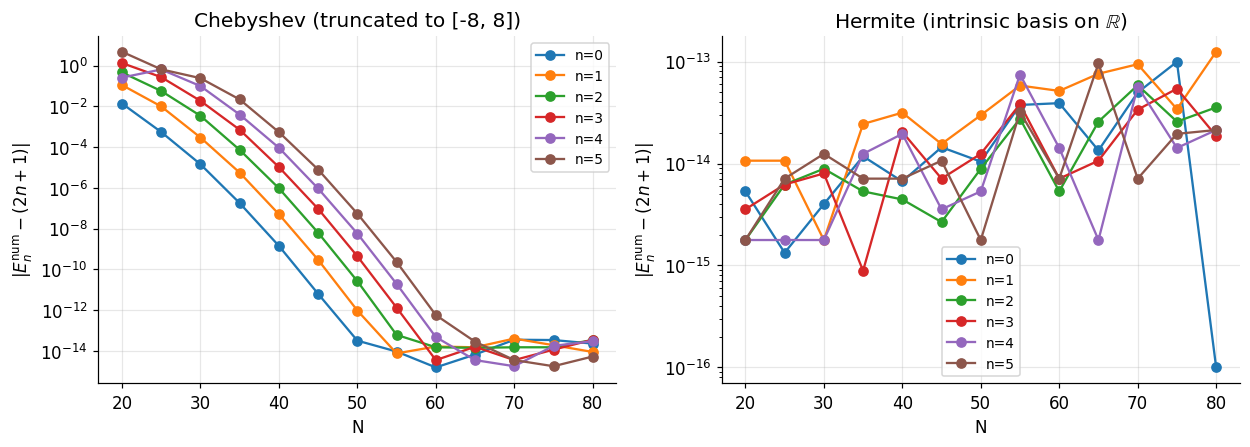

First 8 Hermite eigenvalues at N=60 (exact: 1, 3, 5, 7, 9, 11, 13, 15):
  n=0: 1.0000000000000   error: 3.91e-14
  n=1: 2.9999999999999   error: 5.15e-14
  n=2: 5.0000000000000   error: 5.33e-15
  n=3: 7.0000000000000   error: 7.11e-15
  n=4: 9.0000000000000   error: 1.42e-14
  n=5: 11.0000000000000   error: 7.11e-15
  n=6: 13.0000000000000   error: 1.24e-14
  n=7: 15.0000000000000   error: 1.78e-15


In [8]:
def harmonic_oscillator_hermite(N):
    x, D = hermite_setup(N)
    H = -D @ D + np.diag(x**2)
    E, V = la.eig(H)
    idx = np.argsort(E.real)
    return x, E.real[idx], V[:, idx]


# Hermite results (no truncation, no L parameter to tune)
Ns_h = np.arange(20, 81, 5)
errs_hermite = {n: [] for n in range(8)}
for N in Ns_h:
    _, E_h, _ = harmonic_oscillator_hermite(N)
    for n in range(8):
        errs_hermite[n].append(abs(E_h[n] - (2 * n + 1)))

# Compare to Part-I Chebyshev (truncated at L=8) result
def harmonic_oscillator_cheb(N, L=8.0):
    D, xi = cheb(N)
    x = L * xi
    Dx = D / L
    D2x = Dx @ Dx
    H = -D2x + np.diag(x**2)
    Hi = H[1:-1, 1:-1]
    E, _ = la.eig(Hi)
    return np.sort(E.real)


Ns_c = np.arange(20, 81, 5)
errs_cheb = {n: [] for n in range(8)}
for N in Ns_c:
    E_c = harmonic_oscillator_cheb(N, L=8.0)
    for n in range(8):
        errs_cheb[n].append(abs(E_c[n] - (2 * n + 1)))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.2))
for n in range(6):
    ax[0].semilogy(Ns_c, np.maximum(errs_cheb[n], 1e-16), "o-", label=f"n={n}")
ax[0].set_xlabel("N"); ax[0].set_ylabel(r"$|E_n^{\rm num} - (2n+1)|$")
ax[0].set_title("Chebyshev (truncated to [-8, 8])")
ax[0].legend(fontsize=9)

for n in range(6):
    ax[1].semilogy(Ns_h, np.maximum(errs_hermite[n], 1e-16), "o-", label=f"n={n}")
ax[1].set_xlabel("N"); ax[1].set_ylabel(r"$|E_n^{\rm num} - (2n+1)|$")
ax[1].set_title("Hermite (intrinsic basis on $\\mathbb{R}$)")
ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

print("First 8 Hermite eigenvalues at N=60 (exact: 1, 3, 5, 7, 9, 11, 13, 15):")
_, E_h, _ = harmonic_oscillator_hermite(60)
for n in range(8):
    print(f"  n={n}: {E_h[n]:.13f}   error: {abs(E_h[n] - (2*n+1)):.2e}")

**Note the qualitative difference.** Both methods converge spectrally, but:

* **Chebyshev** stalls at a precision floor that depends on the truncation $L$. To get more digits
  on higher excited states, you'd need to increase $L$ — but that stretches the same number of
  nodes over a wider region, hurting accuracy on the lower states. There's a tradeoff.
* **Hermite** has *no truncation parameter*. Each eigenvalue converges to roundoff at its own rate,
  determined only by how many nodes are needed to resolve $\psi_n$ — and the basis itself
  *is* $\psi_n$.

### When to reach for Hermite

Hermite is the right basis when:

1. The domain is genuinely $(-\infty,\infty)$.
2. The solution has Gaussian-like decay (formally: lies in the Schwartz space $\mathcal{S}(\mathbb{R})$).
3. The problem has a natural length scale matching the Hermite nodes' spread.

Mismatch on (3) is the main pitfall. Hermite nodes spread out roughly like $\sqrt{2N+1}$. If your
solution's natural scale is $\alpha$, rescale via $\tilde x = x/\alpha$ and use Hermite functions in
$\tilde x$. (Boyd, Ch. 17, calls this *Hermite scaling* and it's surprisingly important.)

For algebraic decay (e.g. $1/(1+x^2)$ tails), Hermite is wrong — switch to **rational Chebyshev**
$TB_n(x) = T_n(x/\sqrt{1+x^2})$ instead.

## What's now in the toolkit

After Parts I–III, you have:

* Spectral differentiation (Fourier, Chebyshev, Hermite) and Clenshaw–Curtis quadrature.
* BVP and eigenvalue solvers via row-replacement BCs.
* Heat/wave/Burgers/KdV time-stepping with IFRK4 and ETDRK4.
* 2D Poisson with both dense and fast-diagonalization solvers.
* Domain mapping for finite, semi-infinite, and infinite intervals; Hermite for $(-\infty,\infty)$.

That's a complete, production-quality kit for *forward* problems. Part V tackles the natural next
question: **what if you want to solve an inverse / control problem?** The pseudospectral grid
becomes a transcription tool, the differentiation matrix becomes a defect constraint Jacobian, and
the discrete problem becomes a sparse nonlinear program — perfectly suited to SQP solvers like SNOPT.